In [1]:
from os.path import split

import yfinance as yf
import pandas as pd
import numpy as np
from pyexpat import features

# Download historical data for Apple (AAPL)
ticker = "AAPL"
df = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# Shift 'Close' by -1 so today's features predict tomorrow's close
df['Next_Close'] = df['Close'].shift(-1)

# Drop the very last row
df.dropna(inplace=True)

print(f"Data successfully loaded for {ticker}!")
print(f"Dataset Shape: {df.shape}")
df.head()

[*********************100%***********************]  1 of 1 completed

Data successfully loaded for AAPL!
Dataset Shape: (1254, 6)


Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2021-01-04,125.740837,129.821751,123.165971,129.734307,143301900,127.295441
2021-01-05,127.295441,128.004754,124.788590,125.235554,97664900,123.010521
2021-01-06,123.010521,127.334355,122.796757,124.098768,155088000,127.208031
2021-01-07,127.208031,127.897907,124.234793,124.720617,109578200,128.305984
2021-01-08,128.305984,128.869542,126.537580,128.675200,105158200,125.323051


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define features (X) and target variable (y)
# We use multi-index column access since yfinance returns data with a Ticker row
features = [('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Close', 'AAPL'), ('Volume', 'AAPL')]
X = df[features]
y = df[('Next_Close', '')]

# 2. Chronological split (80% Train, 20% Test) to respect time series structure
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Initialize and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Model training complete on {len(X_train)} historical records!")
print(f"Testing on the remaining {len(X_test)} records.")

Model training complete on 1003 historical records!
Testing on the remaining 251 records.


--- Evaluation Metrics ---
Mean Absolute Error (MAE): $6.83
Root Mean Squared Error (RMSE): $9.75
R2 Score: 0.8646



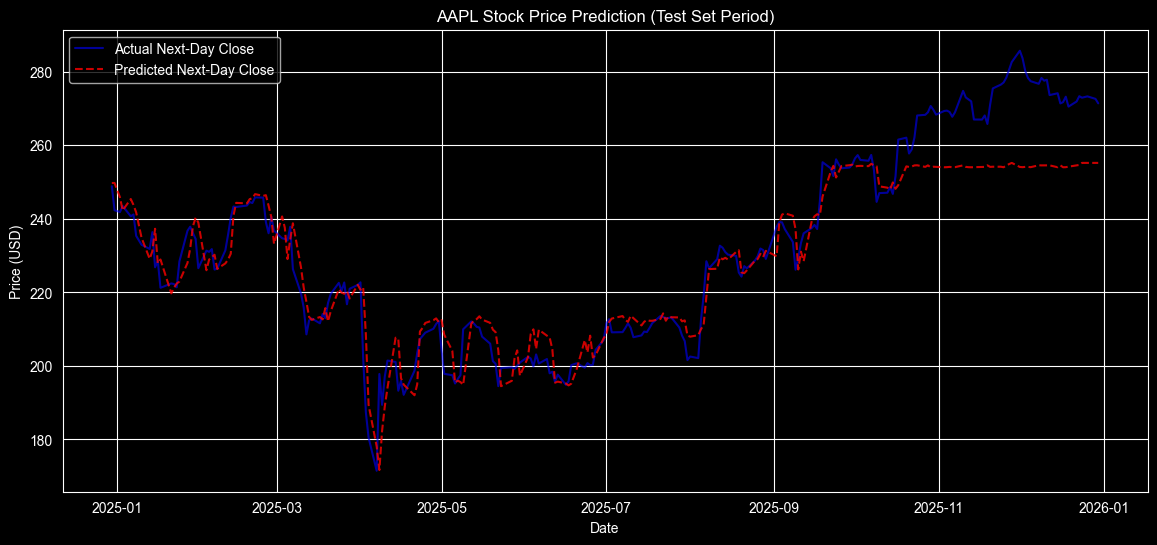

In [5]:
import matplotlib.pyplot as plt

# Make predictions on the test dataset
predictions = model.predict(X_test)

# Calculate regression metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}\n")

# Plotting Actual vs Predicted Prices
plt.figure(figsize=(14, 6))
# We use .values because y_test might have a multi-index name from yfinance
plt.plot(y_test.index, y_test.values, label="Actual Next-Day Close", color="blue", alpha=0.6)
plt.plot(y_test.index, predictions, label="Predicted Next-Day Close", color="red", linestyle="--", alpha=0.8)

plt.title(f"{ticker} Stock Price Prediction (Test Set Period)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()